In [ ]:
pip install kaggle

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

print("Форма:", df.shape)
print(df.head())


Форма: (891, 12)
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   

Кол-во выживших по классам
Pclass
1    63.0
2    47.3
3    24.2
Name: Survived, dtype: float64


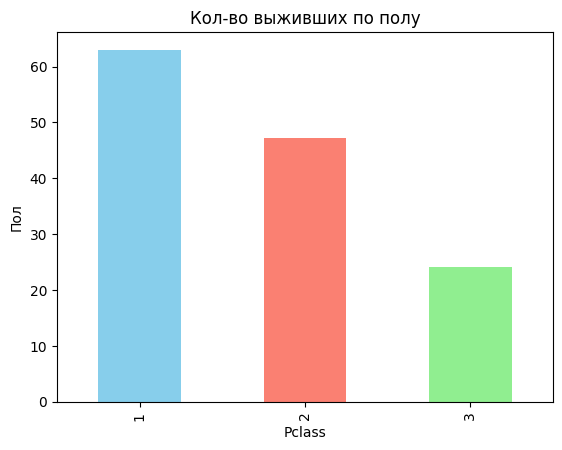

In [ ]:
print("Кол-во выживших по классам")
print(df.groupby('Pclass')['Survived'].mean().round(3) * (100))
(df.groupby('Pclass')['Survived'].mean().round(3) * (100)).plot(kind='bar', color=['skyblue', 'salmon', 'lightgreen'])
plt.title('Кол-во выживших по класам')
plt.ylabel('Пол')
plt.show()


Кол-во выживших по полу
Sex
female    74.2
male      18.9
Name: Survived, dtype: float64


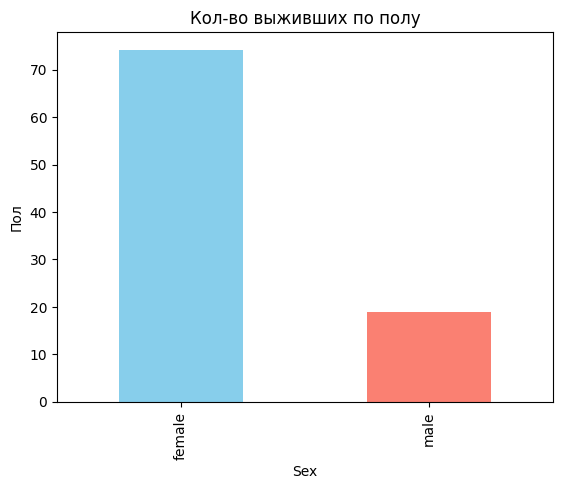

In [ ]:
print("Кол-во выживших по полу")
print(df.groupby('Sex')['Survived'].mean().round(3) * (100))
(df.groupby('Sex')['Survived'].mean().round(3) * (100)).plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Кол-во выживших по полу')
plt.ylabel('Пол')
plt.show()

In [ ]:
Survivors_cross = pd.pivot_table(df,
                                 values = 'Survived',
                                 index = 'Sex',
                                 columns = 'Pclass',
                                 aggfunc = 'mean',
                                 fill_value =0).round(3) * 100
print("Выжившие")
print(Survivors_cross)

Выжившие
Pclass     1     2     3
Sex                     
female  96.8  92.1  50.0
male    36.9  15.7  13.5


In [ ]:
print(" Результаты выживших:")
print("• Женщины 1 класса:", Survivors_cross.loc['female', 1], "%")
print("• Мужчины 3 класса:", Survivors_cross.loc['male', 3], "%")
print("• Самый безопасный профиль:", Survivors_cross.idxmax().max())


 Результаты выживших:
• Женщины 1 класса: 96.8 %
• Мужчины 3 класса: 13.5 %
• Самый безопасный профиль: female
